#  Market Sentiment vs Trader Behavior Analysis

This notebook analyzes how Fear/Greed sentiment impacts trader performance, risk behavior, and trading strategies on Hyperliquid.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load datasets
sentiment_df = pd.read_csv("C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/data/fear_greed_index.csv")
trader_df = pd.read_csv('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/data/historical_data.csv')

In [10]:
#rows and columns
print("Sentiment Data Shape:", sentiment_df.shape)
print("Rows: ",sentiment_df.shape[0],"\nColumns: ",sentiment_df.shape[1])
print("Trader Data Shape:", trader_df.shape)
print("Rows: ",trader_df.shape[0],"Columns: ",trader_df.shape[1])

Sentiment Data Shape: (2644, 4)
Rows:  2644 
Columns:  4
Trader Data Shape: (211224, 16)
Rows:  211224 Columns:  16


In [11]:
#missing values
print("\nMissing values (Sentiment) Column-Wise:")
print(sentiment_df.isnull().sum())
print("\nMissing values (Trader) Column-Wise:")
print(trader_df.isnull().sum())
print("\nTotal Missing values (Sentiment):",sentiment_df.isnull().sum().sum())
print("\nTotal Missing values (Trader):",trader_df.isnull().sum().sum())


Missing values (Sentiment) Column-Wise:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trader) Column-Wise:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Total Missing values (Sentiment): 0

Total Missing values (Trader): 0


In [12]:
print("Sentiment Duplicates:", sentiment_df.duplicated().sum())
print("Trader Duplicates:", trader_df.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


In [13]:
#Convert timestamps & align by date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df['date_only'] = sentiment_df['date'].dt.date
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'],dayfirst=True)
trader_df['date_only'] = trader_df['Timestamp IST'].dt.date
merged_df = pd.merge(trader_df,sentiment_df[['date_only', 'classification']],on='date_only',how='left')

##  Data Preparation

- Cleaned column names and handled missing values  
- Converted timestamps to datetime format  
- Aggregated data at daily level  
- Merged trading data with sentiment classification  

In [14]:
#Daily PnL per trader (account)
daily_pnl = merged_df.groupby(['Account', 'date_only'])['Closed PnL'].sum().reset_index()
print(daily_pnl.head())

                                      Account   date_only  Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1


In [15]:
#Win Rate per trader
merged_df['win'] = merged_df['Closed PnL'] > 0
win_rate = merged_df.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)
print(win_rate.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [16]:
#Average Trade Size
avg_trade_size = merged_df.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)
print(avg_trade_size.head())

                                      Account  avg_trade_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab     8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782


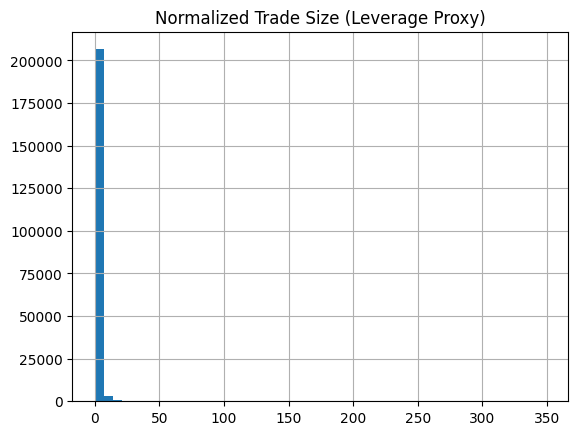

<Figure size 640x480 with 0 Axes>

In [39]:
#Leverage Distribution
# Normalize size per account
merged_df['normalized_size'] = merged_df.groupby('Account')['Size USD'].transform(lambda x: x / x.mean())
# Distribution
merged_df['normalized_size'].hist(bins=50)
plt.title("Normalized Trade Size (Leverage Proxy)")
plt.show()
plt.savefig('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/outputs/Normalised_trade_size.png')

In [18]:
#no of trades per day
trades_per_day = merged_df.groupby('date_only').size().reset_index(name='num_trades')
print(trades_per_day.head())

    date_only  num_trades
0  2023-05-01           3
1  2023-12-05           9
2  2023-12-14          11
3  2023-12-15           2
4  2023-12-16           3


In [19]:
#Long / Short Ratio
long_short = merged_df.groupby(['date_only', 'Side']).size().unstack(fill_value=0)
# Calculate ratio
long_short['long_short_ratio'] = long_short.get('Buy', 0) / (long_short.get('Sell', 1))
print(long_short.head())

Side        BUY  SELL  long_short_ratio
date_only                              
2023-05-01    3     0               0.0
2023-12-05    7     2               0.0
2023-12-14    5     6               0.0
2023-12-15    2     0               0.0
2023-12-16    3     0               0.0


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


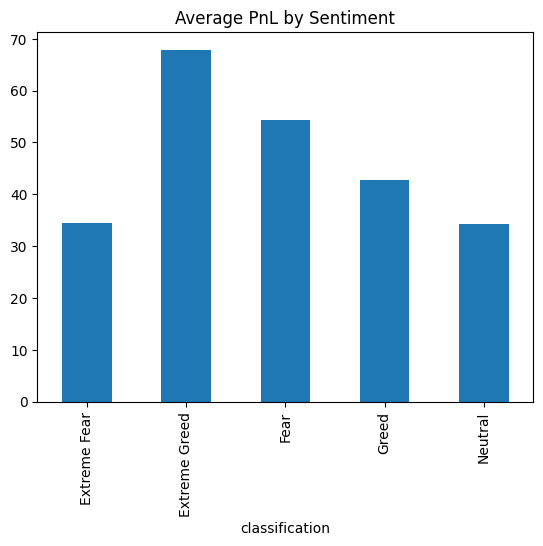

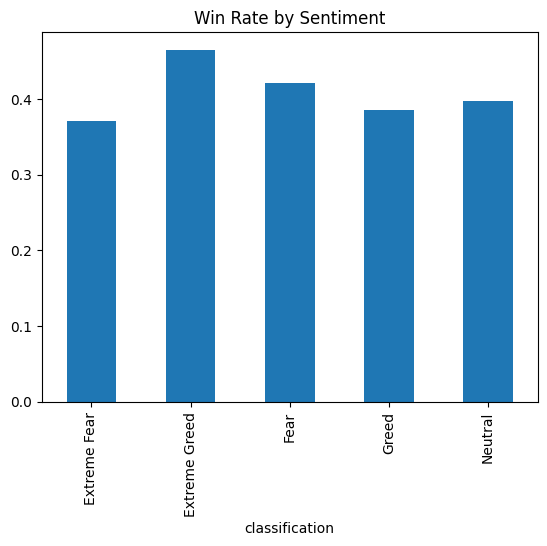

<Figure size 640x480 with 0 Axes>

In [41]:
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)
merged_df['win'] = merged_df['Closed PnL'] > 0
winrate_by_sentiment = merged_df.groupby('classification')['win'].mean()
print(winrate_by_sentiment)
drawdown_proxy = merged_df[merged_df['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()
print(drawdown_proxy)
pnl_by_sentiment.plot(kind='bar', title='Average PnL by Sentiment')
plt.show()
plt.savefig('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/outputs/pnl_vs_sentiment.png')
winrate_by_sentiment.plot(kind='bar', title='Win Rate by Sentiment')
plt.show()
plt.savefig('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/outputs/winrate.png')


classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trades, dtype: float64
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64
Side              BUY   SELL  long_ratio
classification                          
Extreme Fear    10935  10465    0.510981
Extreme Greed   17940  22052    0.448590
Fear            30270  31567    0.489513
Greed           24576  25727    0.488559
Neutral         18969  18717    0.503343


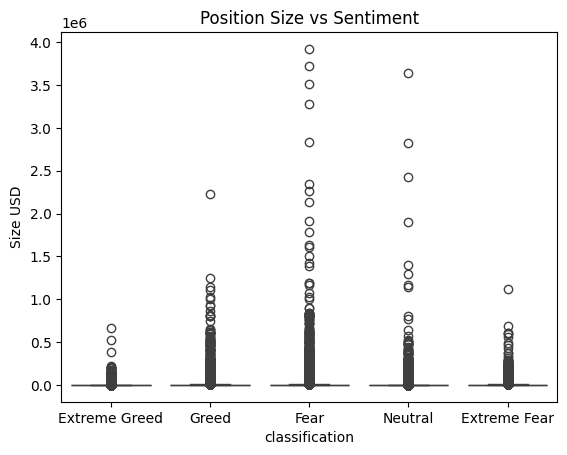

<Figure size 640x480 with 0 Axes>

In [42]:
trades_per_day = merged_df.groupby(['date_only', 'classification']).size().reset_index(name='trades')
freq = trades_per_day.groupby('classification')['trades'].mean()
print(freq)
size_by_sentiment = merged_df.groupby('classification')['Size USD'].mean()
print(size_by_sentiment)
long_short = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
long_short['long_ratio'] = long_short['BUY'] / (long_short['BUY'] + long_short['SELL'])
print(long_short)
sns.boxplot(x='classification', y='Size USD', data=merged_df)
plt.title("Position Size vs Sentiment")
plt.show()
plt.savefig('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/outputs/size_vs_sentiment.png')

In [22]:
#Frequent vs Infrequent Traders
trade_counts = merged_df.groupby('Account').size()
threshold = trade_counts.median()
merged_df['trader_type'] = merged_df['Account'].map(lambda x: 'frequent' if trade_counts[x] > threshold else 'infrequent')
print(merged_df['trader_type'].value_counts())

trader_type
frequent      186957
infrequent     24267
Name: count, dtype: int64


In [23]:
#high risk vs low risk
avg_size = merged_df.groupby('Account')['Size USD'].mean()
threshold_size = avg_size.median()
merged_df['risk_type'] = merged_df['Account'].map(lambda x: 'high_risk' if avg_size[x] > threshold_size else 'low_risk')

In [24]:
#Consistent vs Inconsistent Traders
winrate = merged_df.groupby('Account')['win'].mean()
merged_df['consistency'] = merged_df['Account'].map(lambda x: 'consistent' if winrate[x] > 0.6 else 'inconsistent')

In [25]:
segment_perf = merged_df.groupby(['trader_type', 'risk_type', 'consistency'])['Closed PnL'].mean()
print(segment_perf)

trader_type  risk_type  consistency 
frequent     high_risk  inconsistent    107.502048
             low_risk   consistent       38.319560
                        inconsistent     16.250592
infrequent   high_risk  inconsistent     73.509413
             low_risk   inconsistent    139.053838
Name: Closed PnL, dtype: float64


# Insight 1: Performance vs Market Sentiment

- Highest average PnL is observed during **Extreme Greed**
- Lower PnL during Fear and Extreme Fear periods  
- Indicates traders benefit from strong bullish momentum  

**Conclusion:** Trader profitability improves in bullish sentiment, suggesting momentum-driven gains.
#  Insight 2: Win Rate Behavior

- Win rate is highest during **Extreme Greed**
- Lower success rates during Fear and Greed  
- Suggests better trade accuracy in strong trending markets  

**Conclusion:** Traders are more successful when market direction is clear and positive.
# Insight 3: Risk-Taking Behavior

- Trade sizes are largest during **Fear periods**
- High variability and extreme outliers observed  
- Indicates aggressive “buy-the-dip” or recovery trading  

**Conclusion:** Traders take higher risks during Fear, driven by emotional decision-making.
# Insight 4: Inefficient Risk-Taking

- Despite larger trade sizes during Fear, PnL is lower than Extreme Greed  
- Higher risk does not translate into better returns  

**Conclusion:** Emotional trading during Fear leads to inefficient outcomes.
# Insight 5: Trading Activity

- Trade frequency increases during Greed periods  
- Indicates overtrading behavior in bullish markets  

**Conclusion:** Increased activity does not always improve performance and may reduce consistency.
# Insight 6: Trader Behavior Segments

- Frequent high-risk traders generate higher profits but show inconsistency  
- Infrequent traders achieve more stable performance  
- Low-risk traders exhibit consistent but moderate returns  

**Conclusion:** Aggressive strategies yield high returns but lack stability, while disciplined trading improves consistency.
## Final Conclusion

Market sentiment significantly influences trader behavior and performance:

- Traders perform best during **Extreme Greed**, benefiting from strong market momentum  
- During Fear, traders take excessive risks but achieve lower returns  
- Overtrading and aggressive behavior reduce consistency  

## Strategy Recommendations

1. **Follow momentum in Greed**
   - Increase participation with controlled risk  
   - Favor trend-following strategies  

2. **Reduce risk in Fear**
   - Lower position sizes  
   - Avoid emotional and over-aggressive trading  

Overall, sentiment-aware and disciplined strategies lead to better trading outcomes.

In [26]:
# Sort properly
merged_df = merged_df.sort_values(['Account', 'date_only'])
# Daily PnL per trader
daily_pnl = merged_df.groupby(['Account', 'date_only'])['Closed PnL'].sum().reset_index()
# Create next-day PnL
daily_pnl['next_day_pnl'] = daily_pnl.groupby('Account')['Closed PnL'].shift(-1)
# Create bucket
def pnl_bucket(x):
    if x > 0:
        return 'profit'
    elif x < 0:
        return 'loss'
    else:
        return 'neutral'

daily_pnl['target'] = daily_pnl['next_day_pnl'].apply(pnl_bucket)

In [27]:
features = merged_df.groupby(['Account', 'date_only']).agg({'Closed PnL': 'sum', 'Size USD': 'mean', 'Trade ID': 'count'}).reset_index()

features.rename(columns={ 'Closed PnL': 'daily_pnl', 'Size USD': 'avg_size', 'Trade ID': 'num_trades'}, inplace=True)

In [28]:
features = features.merge( sentiment_df[['date_only', 'classification']], on='date_only', how='left')

In [29]:
model_df = features.merge(daily_pnl[['Account', 'date_only', 'target']],on=['Account', 'date_only'])

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
# Encode sentiment
le = LabelEncoder()
model_df['sentiment'] = le.fit_transform(model_df['classification'])
# Encode target
model_df['target_enc'] = LabelEncoder().fit_transform(model_df['target'])
X = model_df[['daily_pnl', 'avg_size', 'num_trades', 'sentiment']]
y = model_df['target_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.5927505330490405


In [31]:
trader_features = merged_df.groupby('Account').agg({'Closed PnL': 'mean','Size USD': 'mean','Trade ID': 'count'}).reset_index()
trader_features.rename(columns={'Closed PnL': 'avg_pnl','Size USD': 'avg_size','Trade ID': 'trade_count'}, inplace=True)

In [32]:
from sklearn.cluster import KMeans
X = trader_features[['avg_pnl', 'avg_size', 'trade_count']]
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)
print(trader_features.head())

                                      Account     avg_pnl      avg_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   

   trade_count  cluster  
0         3818        0  
1         7280        2  
2         3809        0  
3        13311        2  
4         3239        0  


In [33]:
trader_features['avg_pnl'] = pd.to_numeric(trader_features['avg_pnl'], errors='coerce')
trader_features['avg_size'] = pd.to_numeric(trader_features['avg_size'], errors='coerce')
trader_features['trade_count'] = pd.to_numeric(trader_features['trade_count'], errors='coerce')
cluster_summary = trader_features.groupby('cluster')[['avg_pnl', 'avg_size', 'trade_count']].mean()
print(cluster_summary)

            avg_pnl     avg_size   trade_count
cluster                                       
0        123.416927  7651.668956   2848.217391
1         20.806305  1844.211886  40184.000000
2         33.320731  1802.642744  13191.375000


In [43]:
merged_df.to_csv('C:/Users/Yogita/Desktop/sem4/DAVP/Market -Sentiment-Analysis/data/merged_data.csv', index=False)

## Final Conclusion

Market sentiment significantly influences trader behavior and performance:

- Traders perform best during **Extreme Greed**, benefiting from strong market momentum  
- During Fear, traders take excessive risks but achieve lower returns  
- Overtrading and aggressive behavior reduce consistency  

### Strategy Recommendations

1. **Follow momentum in Greed**
   - Increase participation with controlled risk  
   - Favor trend-following strategies  

2. **Reduce risk in Fear**
   - Lower position sizes  
   - Avoid emotional and over-aggressive trading  

Overall, sentiment-aware and disciplined strategies lead to better trading outcomes.